# Does NBA Salary Predict Performance?

Notebook for the data-driven blog post connecting to past posts on sports salary economics (MLB salary cap, NFL contracts).

**Question:** across the 2025-26 NBA regular season, how strongly does a player's salary correlate with their on-court performance — and are some players producing far more (or less) than their paycheck would suggest?

**Data:** `data/nba_salary_performance_2025_26.csv`, the already-merged result of joining per-game box score performance (`performance_2025_26_cleaned.csv`) with scraped salary data (`salaries_2025_26.csv`) on cleaned player names. Players with fewer than 10 games played or no listed salary have already been dropped. To rebuild it from raw box scores, run `python scripts/build_dataset.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("data/nba_salary_performance_2025_26.csv")
print(f"{len(df)} players with matched salary and performance data")
df[["playerName", "team", "gamesPlayed", "pointsPerGame", "productionPerGame", "salary"]].head()

456 players with matched salary and performance data


,playerName,team,gamesPlayed,pointsPerGame,productionPerGame,salary
0,LeBron James,LAL,60,20.93,33.00,52627153.0
1,Chris Paul,TOR,16,2.94,7.69,2296274.0
2,Kyle Lowry,PHI,14,1.21,2.63,2296274.0
3,Kevin Durant,HOU,78,25.97,34.75,54708609.0
4,Al Horford,GSW,46,8.09,16.22,5685000.0


## Explore: salary vs. performance

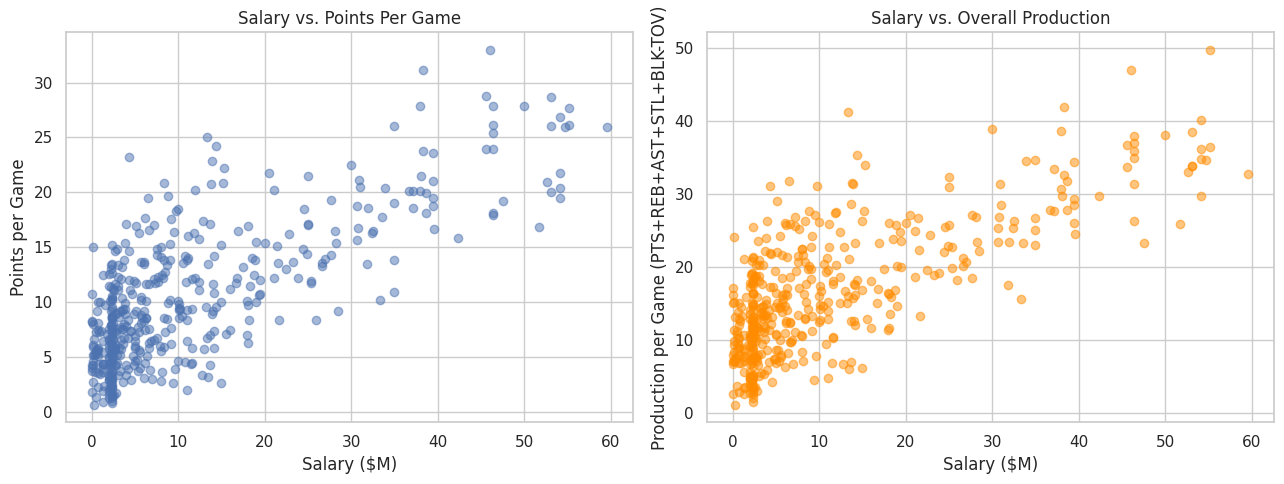

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["salary"] / 1e6, df["pointsPerGame"], alpha=0.5)
axes[0].set_xlabel("Salary ($M)")
axes[0].set_ylabel("Points per Game")
axes[0].set_title("Salary vs. Points Per Game")

axes[1].scatter(df["salary"] / 1e6, df["productionPerGame"], alpha=0.5, color="darkorange")
axes[1].set_xlabel("Salary ($M)")
axes[1].set_ylabel("Production per Game (PTS+REB+AST+STL+BLK-TOV)")
axes[1].set_title("Salary vs. Overall Production")

plt.tight_layout()
plt.show()

## Correlation and regression

In [4]:
for metric in ["pointsPerGame", "productionPerGame"]:
    r, p_value = stats.pearsonr(df["salary"], df[metric])
    slope, intercept, r_value, p_lr, std_err = stats.linregress(df["salary"], df[metric])
    print(f"Salary vs. {metric}:")
    print(f"  Pearson r = {r:.3f}, p = {p_value:.4g}")
    print(f"  R-squared = {r_value**2:.3f}")
    print()

Salary vs. pointsPerGame:
  Pearson r = 0.758, p = 3.446e-86
  R-squared = 0.574

Salary vs. productionPerGame:
  Pearson r = 0.745, p = 6.089e-82
  R-squared = 0.555



## Value for money: rookie-scale vs. veteran-max contracts

Production per $1M of salary, compared across two salary tiers.

In [5]:
df["prod_per_million"] = df["productionPerGame"] / (df["salary"] / 1e6)

rookie_scale = df[df["salary"] < 5_000_000]
veteran_max = df[df["salary"] > 30_000_000]

t_stat, p_value = stats.ttest_ind(
    rookie_scale["prod_per_million"],
    veteran_max["prod_per_million"],
)

print(f"Rookie-scale (<$5M, n={len(rookie_scale)}): {rookie_scale['prod_per_million'].mean():.2f} production/$M")
print(f"Veteran-max (>$30M, n={len(veteran_max)}): {veteran_max['prod_per_million'].mean():.2f} production/$M")
print(f"t-statistic = {t_stat:.2f}, p = {p_value:.4g}")

Rookie-scale (<$5M, n=212): 14.69 production/$M
Veteran-max (>$30M, n=56): 0.75 production/$M
t-statistic = 2.80, p = 0.00547


## Best and worst value-for-money seasons

Among players making at least $1M, ranked by production per dollar.

In [6]:
min_salary_pool = df[df["salary"] >= 1_000_000]
cols = ["playerName", "team", "salary", "productionPerGame", "prod_per_million"]

print("Best value:")
display(min_salary_pool.sort_values("prod_per_million", ascending=False)[cols].head(10))

print("Worst value:") 
display(min_salary_pool.sort_values("prod_per_million", ascending=True)[cols].head(10))

Best value:


,playerName,team,salary,productionPerGame,prod_per_million
440,Maxime Raynaud,SAC,1272870.0,21.09,16.568856
358,Olivier-Maxence Prosper,DAL,1002360.0,14.60,14.565625
407,Jamir Watkins,WAS,1131970.0,13.36,11.802433
7,Russell Westbrook,SAC,2296274.0,25.49,11.100592
266,Micah Potter,IND,1527805.0,15.96,10.446359
348,Toumani Camara,POR,2221677.0,20.81,9.366798
314,Collin Gillespie,PHO,2296274.0,21.26,9.258477
365,Pelle Larsson,MIA,1955377.0,17.78,9.092876
176,Neemias Queta,BOS,2349578.0,21.36,9.090994
193,Precious Achiuwa,SAC,2111516.0,18.88,8.941443


Worst value:


,playerName,team,salary,productionPerGame,prod_per_million
95,Jonathan Isaac,ORL,15000000.0,6.17,0.411333
112,Maxi Kleber,LAL,11000000.0,4.86,0.441818
33,Kelly Olynyk,SAS,13445122.0,6.01,0.447002
30,Khris Middleton,DAL,33296296.0,15.70,0.471524
71,Pat Connaughton,CHO,9423869.0,4.52,0.479633
42,Zach LaVine,SAC,47499660.0,23.31,0.490740
18,Paul George,PHI,51666090.0,25.90,0.501296
198,Josh Green,CHO,13666667.0,6.96,0.509268
88,Dorian Finney-Smith,HOU,12700000.0,6.80,0.535433
25,Jimmy Butler III,GSW,54126450.0,29.72,0.549085


## Takeaway

Salary and performance are meaningfully correlated (r ≈ 0.75-0.76, R² ≈ 0.55-0.57) — teams are not paying at random — but salary alone explains only a bit more than half the variance in production. Rookie-scale players deliver far more production per dollar than max-contract veterans, which is mostly the salary-cap structure working as designed rather than a market inefficiency. The more interesting inefficiency shows up in individual veteran-max contracts that are underperforming their price tag relative to role players and rookie-scale standouts.